# Handwritten Digit Classification Using the MNIST Dataset

**Course:** AIT 736 Applied Machine Learning  
**Final Project:** Handwritten Digit Classification  
**Goal:** Build, train, evaluate, and interpret a machine learning model that classifies handwritten digits from 0 to 9.

This notebook uses TensorFlow/Keras to build a Convolutional Neural Network (CNN) for MNIST digit classification.


## 1. Import Libraries

We use TensorFlow/Keras for the model, NumPy for data processing, Matplotlib for visualization, and scikit-learn for evaluation metrics.


In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)


## 2. Load the MNIST Dataset

The MNIST dataset contains grayscale images of handwritten digits.  
Each image is 28 × 28 pixels, and each label is a digit from 0 to 9.


In [3]:
# Load MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


## 3. Explore the Data

We display a few sample images to understand what the handwritten digits look like.


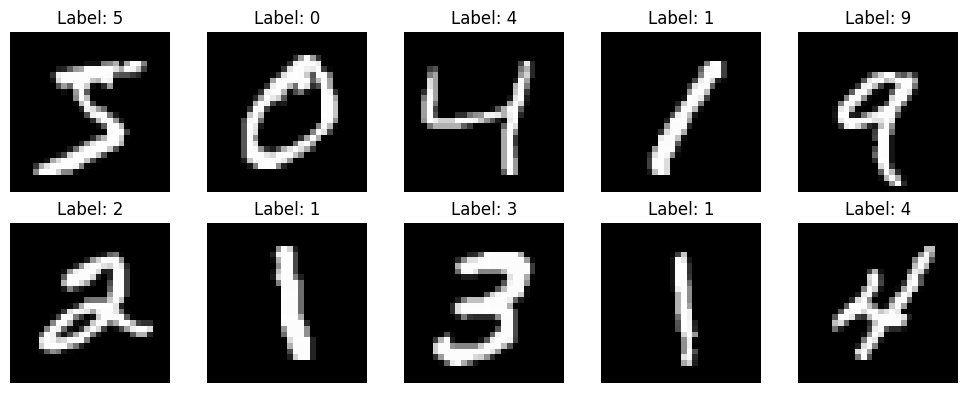

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Check Class Distribution

This helps us see whether the dataset is balanced across digits 0–9.


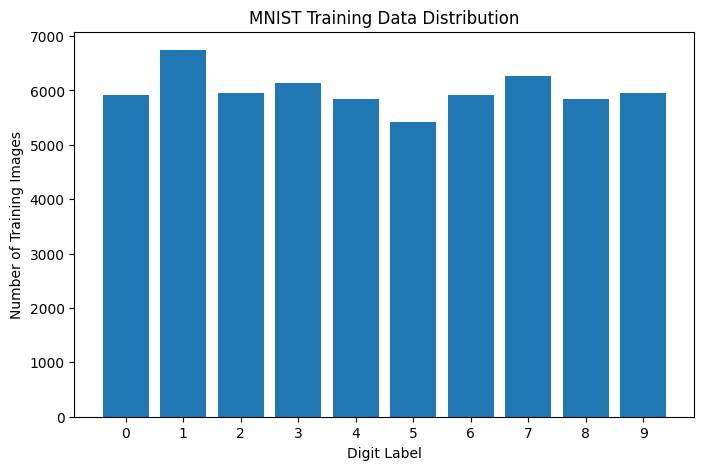

Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


In [5]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(unique, counts)
plt.xlabel("Digit Label")
plt.ylabel("Number of Training Images")
plt.title("MNIST Training Data Distribution")
plt.xticks(unique)
plt.show()

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")


## 5. Data Preprocessing

We perform three important preprocessing steps:

1. Normalize pixel values from 0–255 to 0–1.
2. Reshape images to include one channel because they are grayscale images.
3. Convert labels into one-hot encoded format for multiclass classification.


In [6]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape to CNN input format: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Save original test labels before one-hot encoding
y_test_original = y_test.copy()

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Preprocessed training shape:", X_train.shape)
print("Preprocessed test shape:", X_test.shape)
print("One-hot label example:", y_train_cat[0])


Preprocessed training shape: (60000, 28, 28, 1)
Preprocessed test shape: (10000, 28, 28, 1)
One-hot label example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 6. Build the CNN Model

A Convolutional Neural Network is suitable for image classification because it can learn spatial patterns such as edges, curves, and digit shapes.

Model structure:
- Convolution layer
- Max pooling layer
- Second convolution layer
- Max pooling layer
- Flatten layer
- Dense hidden layer
- Dropout layer
- Softmax output layer


In [7]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

We train the model using the training set and reserve part of the training data as a validation set.


In [8]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 104ms/step - accuracy: 0.9164 - loss: 0.2796 - val_accuracy: 0.9822 - val_loss: 0.0617
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9774 - loss: 0.0742 - val_accuracy: 0.9857 - val_loss: 0.0497
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9837 - loss: 0.0539 - val_accuracy: 0.9883 - val_loss: 0.0441
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.9867 - loss: 0.0430 - val_accuracy: 0.9902 - val_loss: 0.0363
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0.9907 - val_loss: 0.0368


## 8. Visualize Training Performance

We plot training and validation accuracy/loss to check whether the model is learning properly.


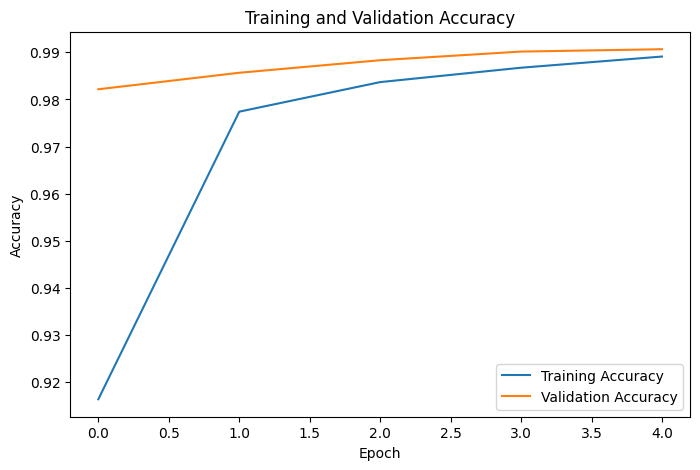

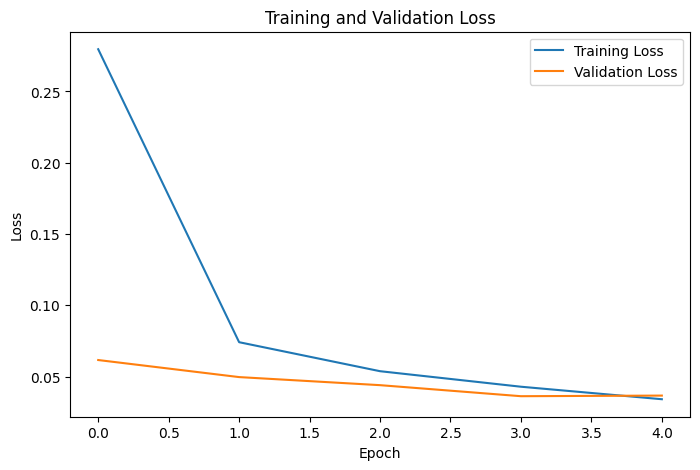

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


## 9. Evaluate the Model on the Test Set

We evaluate model performance using test accuracy.


In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.0302
Test Accuracy: 0.9900


## 10. Classification Report

The classification report shows precision, recall, and F1-score for each digit.


In [11]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_original, y_pred))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 11. Confusion Matrix

The confusion matrix helps identify which digits are most often confused by the model.


<Figure size 800x800 with 0 Axes>

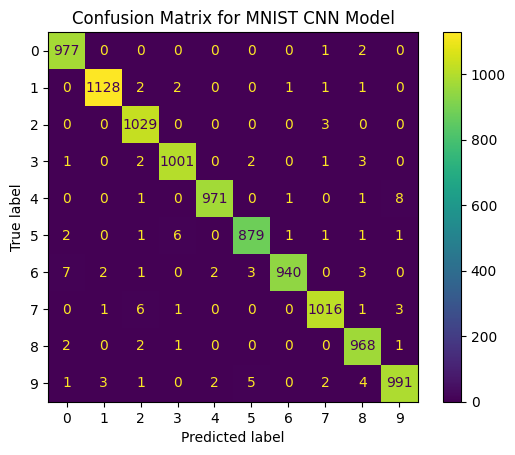

In [12]:
cm = confusion_matrix(y_test_original, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(values_format="d")
plt.title("Confusion Matrix for MNIST CNN Model")
plt.show()


## 12. Show Correct and Incorrect Predictions

This section displays some correctly classified and misclassified examples.


In [13]:
correct_indices = np.where(y_pred == y_test_original)[0]
incorrect_indices = np.where(y_pred != y_test_original)[0]

print("Number of correct predictions:", len(correct_indices))
print("Number of incorrect predictions:", len(incorrect_indices))


Number of correct predictions: 9900
Number of incorrect predictions: 100


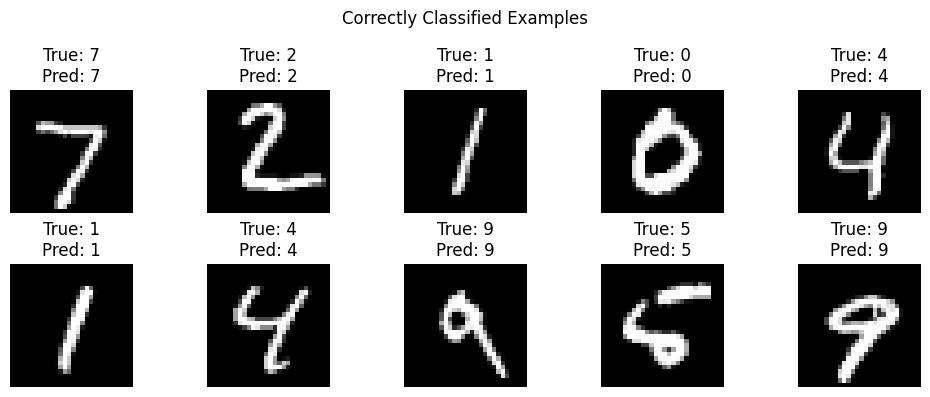

In [14]:
# Display correctly classified examples
plt.figure(figsize=(10, 4))

for i, idx in enumerate(correct_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_test_original[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.suptitle("Correctly Classified Examples")
plt.tight_layout()
plt.show()


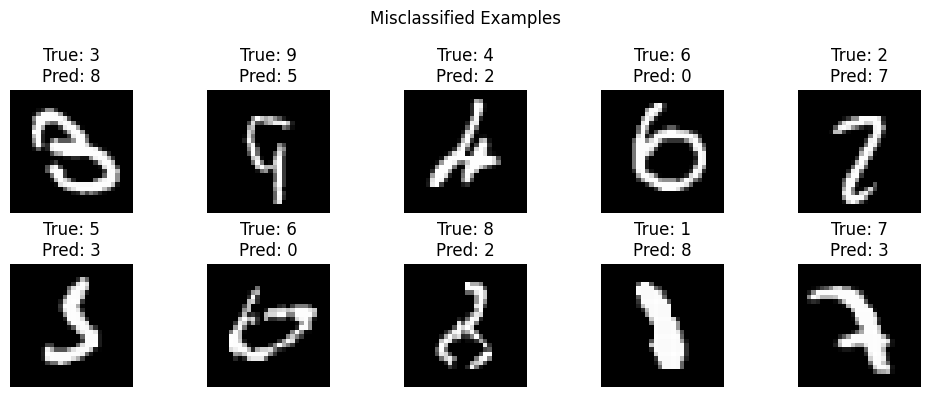

In [15]:
# Display misclassified examples
plt.figure(figsize=(10, 4))

for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_test_original[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.suptitle("Misclassified Examples")
plt.tight_layout()
plt.show()


## 13. Conclusion

In this project, we built a CNN model for handwritten digit classification using the MNIST dataset.  
The model learned visual patterns from 28 × 28 grayscale images and achieved strong test accuracy.

Key findings:
- CNN is effective for image classification because it captures spatial features.
- Normalization helps improve training stability.
- Confusion matrix and misclassified examples help us understand model errors.
- Most mistakes happen when handwritten digits have similar shapes, such as 3 and 5 or 4 and 9.

Possible future improvements:
- Train for more epochs.
- Try data augmentation.
- Compare CNN with Logistic Regression, KNN, or Decision Tree.
- Deploy the model using Streamlit or Flask.
